# Proyek Analisis Data: [Bike Sharing Dataset]
- **Nama:** [Alifah Mu'asyaroh]
- **Email:** [alifahmuasyaroh@gmail.com]
- **ID Dicoding:** [CDCC229D6X1533]

## Menentukan Pertanyaan Bisnis

- Bagaimana pola penggunaan sepeda pada hari kerja dan akhir pekan berdasarkan jam?
- Bagaimana perbedaan penggunaan sepeda antara pengguna casual dan pengguna registered berdasarkan jam?

## Import Semua Packages/Library yang Digunakan

Tahap ini bertujuan untuk mengimpor berbagai library yang akan dibutuhkan dalam proses analisis.

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling
Tahap ini bertujuan untuk membersihkan dan mempersiapkan dataset agar siap dianalisis.

### Gathering Data
Tahap ini bertujuan untuk mengumpulkan dataset yang akan digunakan dalam proses analisis.

In [34]:
# Memuat dataset hours
hours_df = pd.read_csv('/content/bike_sharing/hour.csv')
hours_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Dataset hour.csv berhasil dimuat.
- Dataset berisi data penyewaan sepeda yang dicatat per jam.
- Terdapat variabel-variabel yang meliputi waktu, kondisi cuaca, dan tipe pengguna.


### Assessing Data
Tahap ini bertujuan untuk memeriksa kualitas dataset dengan mengidentifikasi permasalahan yang ada, seperti missing value, data duplikat, serta kesalahan tipe data.

In [35]:
# Memeriksa tipe data dan missing value
hours_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [36]:
# Cek duplikasi data
print("Jumlah duplikasi: ", hours_df.duplicated().sum())

Jumlah duplikasi:  0


In [37]:
# Memeriksa parameter statistik
hours_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [38]:
# Cek data hum yang bernilai 0
hours_df[hours_df['hum'] == 0]

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
1551,1552,2011-03-10,1,0,3,0,0,4,1,3,0.34,0.3182,0.0,0.2537,3,0,3
1552,1553,2011-03-10,1,0,3,1,0,4,1,3,0.34,0.3182,0.0,0.2537,0,2,2
1553,1554,2011-03-10,1,0,3,2,0,4,1,3,0.34,0.3182,0.0,0.2537,0,1,1
1554,1555,2011-03-10,1,0,3,5,0,4,1,3,0.36,0.3485,0.0,0.1940,1,2,3
1555,1556,2011-03-10,1,0,3,6,0,4,1,3,0.36,0.3333,0.0,0.3284,0,12,12
1556,1557,2011-03-10,1,0,3,7,0,4,1,3,0.38,0.3939,0.0,0.2239,1,36,37
1557,1558,2011-03-10,1,0,3,8,0,4,1,3,0.38,0.3939,0.0,0.2836,1,43,44
1558,1559,2011-03-10,1,0,3,9,0,4,1,3,0.40,0.4091,0.0,0.2239,1,23,24
1559,1560,2011-03-10,1,0,3,10,0,4,1,3,0.40,0.4091,0.0,0.1642,0,17,17
1560,1561,2011-03-10,1,0,3,11,0,4,1,3,0.40,0.4091,0.0,0.2537,6,5,11


**Insight:**
- Dataset memuat 17.379 baris dan 17 kolom
- Semua kolom memiliki jumlah non-null yang sama, sehingga tidak ada missing value
- Kolom dteday bertipe object, sehingga perlu diubah menjadi datetime
- Kolom season, yr, mnth, holiday, weekday, workingday, dan weathersit adalah data kategori yang direpresentasikan ke dalam numerik
- Nilai pada variabel cnt (jumlah rental) memiliki rata-rata sekitar 189 sepeda per jam, dengan nilai maksimum mencapai 977 sepeda per jam.
- Pada cnt terdapat perbedaan yang cukup besar antara nilai minimum dan maksimum yang menunjukkan adanya variasi penggunaan sepeda yang tinggi
- Jumlah pengguna registered jauh lebih tinggi dibandingkan pengguna casual
- Variabel cuaca yang meliputi temp, atemp, hum, dan windspeed dalam bentuk numerik dan siap digunakan untuk analisis
- Nilai minimum hum sebesar 0 secara realita jarang terjadi, sehingga berpotensi sebagai anomali data

### Cleaning Data
Tahap ini bertujuan untuk memperbaiki dan membersihkan data dari permasalahan yang telah diidentifikasi sebelumnya.

In [39]:
# Mengubah tipe data pada dteday
hours_df['dteday'] = pd.to_datetime(hours_df['dteday'])

In [40]:

# Mengubah tipe data dan label pada season, yr, mnth, holiday, weekday, workingday, dan weathersit
# season
hours_df['season'] = hours_df['season'].map({
    1: 'Springer', 2: 'Summer', 3: 'Fall', 4: 'Winter'
}).astype('category')

# yr
hours_df['yr'] = hours_df['yr'].map({
    0: '2011', 1: '2012'
}).astype('category')

# mnth
hours_df['mnth'] = hours_df['mnth'].map({
    1: 'January', 2: 'February', 3: 'March', 4: 'April',
    5: 'May', 6: 'June', 7: 'July', 8: 'August',
    9: 'September', 10: 'October', 11: 'November', 12: 'December'
}).astype('category')

# holiday
hours_df['holiday'] = hours_df['holiday'].map({
    0: 'No', 1: 'Yes'
}).astype('category')

# weekday
hours_df['weekday'] = hours_df['weekday'].map({
    0: 'Sunday', 1: 'Monday', 2: 'Tuesday', 3: 'Wednesday',
    4: 'Thursday', 5: 'Friday', 6: 'Saturday'
}).astype('category')

# workingday
hours_df['workingday'] = hours_df['workingday'].map({
    0: 'No', 1: 'Yes'
}).astype('category')

# weathersit
hours_df['weathersit'] = hours_df['weathersit'].map({
    1: 'Clear',
    2: 'Mist + Cloudy',
    3: 'Light Snow',
    4: 'Heavy Rain'
}).astype('category')

In [41]:
# Cek ulang tipe data
hours_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  category      
 3   yr          17379 non-null  category      
 4   mnth        17379 non-null  category      
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  category      
 7   weekday     17379 non-null  category      
 8   workingday  17379 non-null  category      
 9   weathersit  17379 non-null  category      
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

In [42]:
# Ganti nilai hum 0 dengan median
hours_df['hum'] = hours_df['hum'].replace(0, hours_df['hum'].median())

# Cek nilai hum 0
(hours_df['hum'] == 0).sum()

np.int64(0)

In [43]:
# Cek ulang data
hours_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Springer,2011,January,0,No,Saturday,No,Clear,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,Springer,2011,January,1,No,Saturday,No,Clear,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,Springer,2011,January,2,No,Saturday,No,Clear,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,Springer,2011,January,3,No,Saturday,No,Clear,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,Springer,2011,January,4,No,Saturday,No,Clear,0.24,0.2879,0.75,0.0,0,1,1


In [44]:
# Menyimpan dataset bersih untuk membuat dashboard
hours_df.to_csv('main_data.csv', index=False)

**Insight:**
- Kolom dteday berhasil dikonversi dari tipe object menjadi datetime
- Variabel season, yr, mnth, holiday, weekday, workingday, dan weathersit telah diubah menjadi tipe category dan diberi label deskriptif
- Nilai hum 0 telah ditangani dengan menggunakan median
- Struktur dataset siap digunakan untuk proses exploratory data analysis (EDA)

## Exploratory Data Analysis (EDA)

### Explore Pola Penggunaan Sepeda Berdasarkan Jam

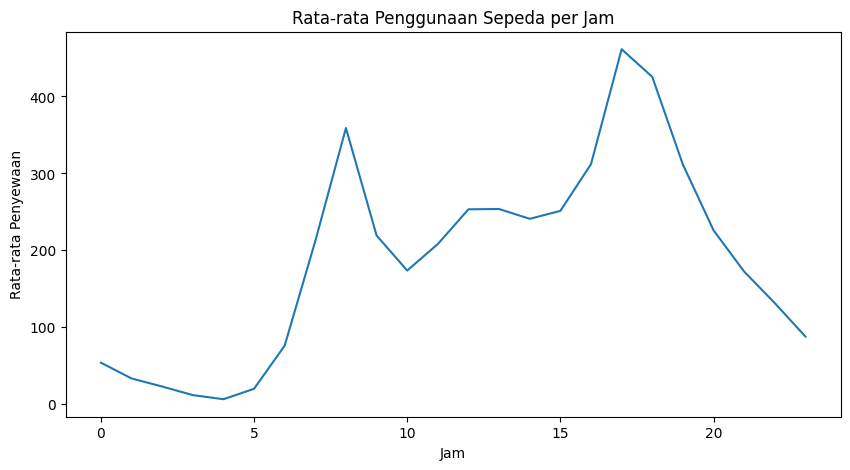

In [45]:
# Mengelompokkan data berdasarkan rata-rata penggunaan sepeda
hourly_usage = hours_df.groupby('hr')['cnt'].mean()

# Visualisasi rata-rata penggunaan sepeda per jam
plt.figure(figsize=(10,5))
sns.lineplot(x=hourly_usage.index, y=hourly_usage.values)
plt.title('Rata-rata Penggunaan Sepeda per Jam')
plt.xlabel('Jam')
plt.ylabel('Rata-rata Penyewaan')
plt.show()

**Insight:**
- Penggunaan sepeda pada pukul 00.00-05.00 sangat rendah
- Terjadi peningkatan yang signifikan pada pagi hari dan mencapai pada puncak pertama sekitar pukul 08.00
- Pada siang hari, penggunaan sepeda sedikit menurun namun tetap pada tingkat menengah
- Terjadi puncak penggunaan sepeda tertinggi pada sore hari sekitar pukul 17.00-18.00
- Jumlah penyewaan kembali menurun setelah sore hari hingga malam hari

### Explore Pola Penggunaan Sepeda pada Hari Kerja dan Akhir Pekan

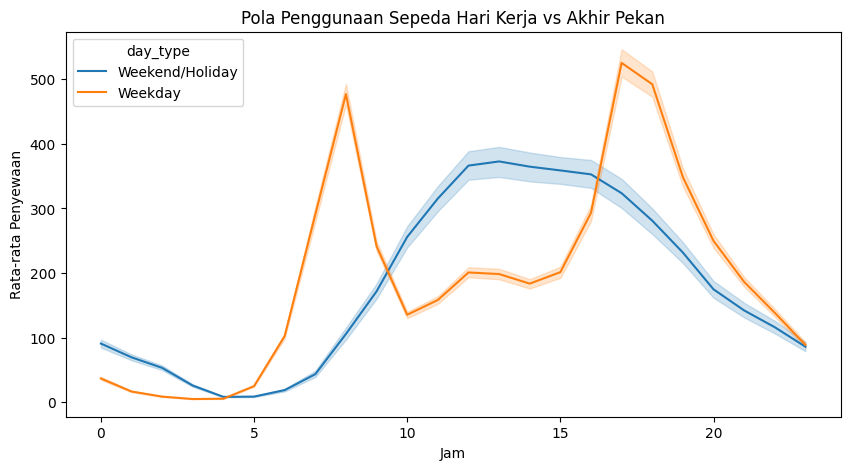

In [46]:
# Membuat kategori hari
hours_df['day_type'] = hours_df['workingday'].map({
    'Yes': 'Weekday',
    'No': 'Weekend/Holiday'
})

# Visualisasi pola penggunaan sepeda berdasarkan hari
plt.figure(figsize=(10,5))
sns.lineplot(data=hours_df, x='hr', y='cnt', hue='day_type')
plt.title('Pola Penggunaan Sepeda Hari Kerja vs Akhir Pekan')
plt.xlabel('Jam')
plt.ylabel('Rata-rata Penyewaan')
plt.show()

**Insight:**
- Terdapat perbedaan pola penggunaan sepeda pada hari kerja dan akhir pekan
- Pada hari kerja, terdapat lonjakan penggunaan sepeda pada pagi hari sekitar pukul 08.00, kemudian setelahnya penggunaan sepeda menurun
- Penggunaan sepeda meningkat kembali hingga mencapai titik tertinggi pada sore hari sekitar pukul 17.00-18.00
- Pada akhir pekan, cenderung meningkat secara perlahan mulai dari pagi hari hingga siang hari, kemudian stabil hingga sore hari
- Pada siang hari hingga sore hari sekitar pukul 11.00-16.00 penggunaan sepeda pada akhir pekan terlihat lebih tinggi dibandingkan pada hari kerja
- Puncak penggunaan sepeda pada akhir pekan tidak setinggi pada hari kerja, namun distribusinya lebih merata sepanjang hari
- Secara keseluruhan, pola penggunaan sepeda pada hari kerja memiliki cenderung lebih fluktuatif dengan perubahan yang jauh berbeda, sedangkan pada akhir pekan cenderung lebih stabil

### Explore Perbandingan Pengguna Sepeda Casual dan Registered

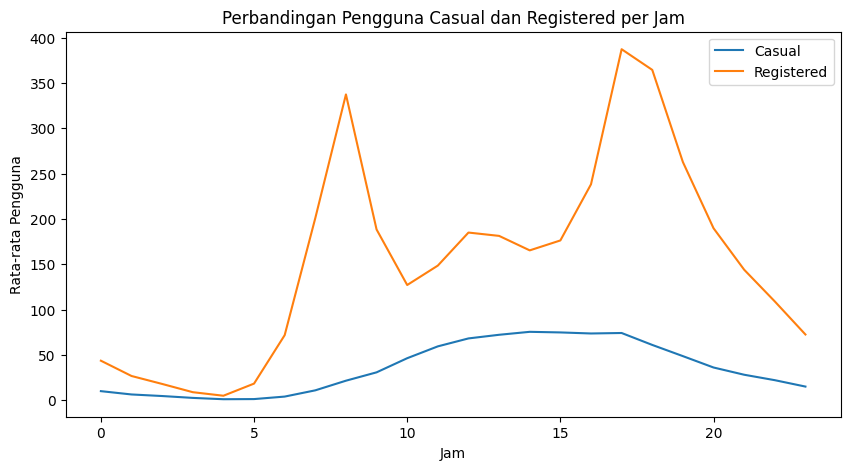

In [47]:
# Mengelompokkan data berdasarkan jam dan rata-rata pengguna
hourly_users = hours_df.groupby('hr')[['casual','registered']].mean()

# Visualisasi perbandingan pola penggunaan
plt.figure(figsize=(10,5))
plt.plot(hourly_users.index, hourly_users['casual'], label='Casual')
plt.plot(hourly_users.index, hourly_users['registered'], label='Registered')
plt.title('Perbandingan Pengguna Casual dan Registered per Jam')
plt.xlabel('Jam')
plt.ylabel('Rata-rata Pengguna')
plt.legend()
plt.show()

**Insight:**
- Jumlah pengguna sepeda registered cenderung lebih tinggi dibandingkan pengguna sepeda casual pada hampir seluruh jam
- Pengguna sepeda registered menunjukkan pola dengan lonjakan yang cukup signifikan pada waktu-waktu tertentu, terutama pada pagi hari dan sore hari
- Pengguna sepeda casual menunjukkan peningkatan yang lebih perlahan dari pagi hari hingga sore hari
- Puncak penggunaan sepeda casual terjadi pada sore hari, namun tidak setinggi pengguna sepeda registered
- Pada malan hari hingga dini hari, kedua pengguna sepeda relatif rendah
- Secara keseluruhan, pola penggunaan sepeda registered terlihat lebih fluktuatif, sementara itu pengguna sepeda casual menunjukkan pola yang lebih stabil dan landai

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana pola penggunaan sepeda pada hari kerja dan akhir pekan berdasarkan jam?

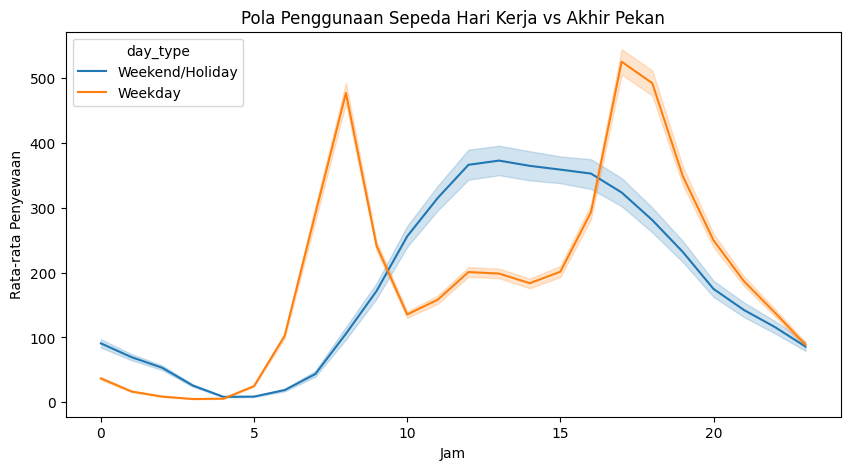

In [48]:
# Visualisasi pola penggunaan sepeda berdasarkan hari
plt.figure(figsize=(10,5))
sns.lineplot(data=hours_df, x='hr', y='cnt', hue='day_type')
plt.title('Pola Penggunaan Sepeda Hari Kerja vs Akhir Pekan')
plt.xlabel('Jam')
plt.ylabel('Rata-rata Penyewaan')
plt.show()

**Insight:**
- Pada hari kerja, penggunaan sepeda menunjukkan dua titik puncak, yaitu pada pagi hari sekitar pukul 08.00 dan sore hari sekitar pukul 17.00-18.00. Pola ini menunjukkan bahwa penggunaan sepeda banyak dimanfaatkan sebagai sarana transportasi untuk berangkat dan pulang kerja
- Pada akhir pekan, tidak terlihat peningkatan yang signifikan di pagi hari. Penggunaan sepeda cenderung meningkat secara perlahan mulai dari pagi hari hingga siang hari, kemudian cenderung stabil hingga sore hari. Hal ini menunjukkan bahwa sepeda dimanfaatkan untuk aktivitas santai atau rekreasi
- Selain itu, pada rentang siang hari hingga sore hari, jumlah penggunaan sepeda di akhir pekan cenderung lebih tinggi dibandingkan dengan hari kerja. Perbedaan ini menandakan adanya perbedaan pola penggunaan sepeda antara hari kerja yang cenderung lebih terjadwal dan akhir pekan yang cenderung lebih fleksibel

### Pertanyaan 2: Bagaimana perbedaan penggunaan sepeda antara pengguna casual dan pengguna registered berdasarkan jam?

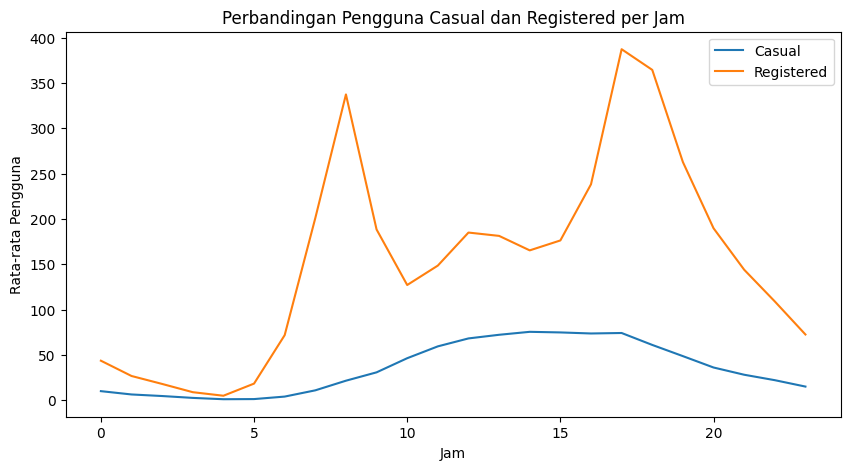

In [49]:
# Mengelompokkan data berdasarkan jam dan rata-rata pengguna
hourly_users = hours_df.groupby('hr')[['casual','registered']].mean()

# Visualisasi perbandingan pola penggunaan
plt.figure(figsize=(10,5))
plt.plot(hourly_users.index, hourly_users['casual'], label='Casual')
plt.plot(hourly_users.index, hourly_users['registered'], label='Registered')
plt.title('Perbandingan Pengguna Casual dan Registered per Jam')
plt.xlabel('Jam')
plt.ylabel('Rata-rata Pengguna')
plt.legend()
plt.show()

**Insight:**
- Pengguna sepeda registered mendominasi penggunaan sepeda, terutama pada jam-jam sibuk, seperti pagi hari sekitar pukul 08.00 dan sore hari sekitar pukul 17.00-18.00. Ini menunjukkan bahwa pengguna sepeda registered cenderung memanfaatkan sepeda untuk aktivitas rutin, seperti bekerja atau bersekolah
- Pengguna sepeda casual tidak menunjukkan peningkatan yang signifikan di pagi hari. Penggunaannya cenderung naik secara perlahan sepanjang hari dan mencapai puncak pada sore hari. Hal ini menunjukkan bahwa pengguna sepeda casual lebih sering memanfaatkan sepeda untuk aktivitas santai atau rekreasi
- Perbedaan ini menggambarkan adanya dua karakteristik pengguna yang berbeda, yaitu pengguna rutin (registered) dan pengguna non-rutin (casual). Dengan demikian, waktu penggunaan sepeda sangat dipengaruhi oleh jenis penggunanya

## Analisis Lanjutan



### Pola Penggunaan Sepeda Berdasarkan Kategori Waktu

Analisis ini bertujuan untuk mengelompokkan penggunaan sepeda berdasarkan kategori waktu untuk mengidentifikasi pola penggunaan sepeda.

In [50]:
# Mengelompokkan jam ke dalam kategori waktu
def categorize_hour(hour):
  if 0 <= hour < 5:
    return 'Dini Hari'
  elif 5 <= hour < 11:
    return 'Pagi Hari'
  elif 11 <= hour < 15:
    return 'Siang Hari'
  elif 15 <= hour < 18:
    return 'Sore Hari'
  else:
    return 'Malam Hari'

hours_df['time_category'] = hours_df['hr'].apply(categorize_hour)

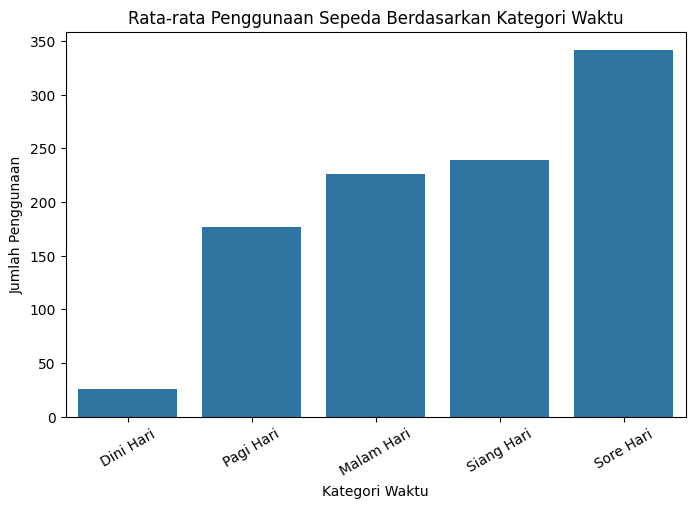

In [51]:
# Mengelompokkan data berdasarkan kategori waktu
time_usage = hours_df.groupby('time_category')['cnt'].mean().sort_values()

# Visualisasi rata-rata penggunaan sepeda berdasarkan kategori waktu
plt.figure(figsize=(8,5))
sns.barplot(x=time_usage.index, y=time_usage.values)
plt.title('Rata-rata Penggunaan Sepeda Berdasarkan Kategori Waktu')
plt.xlabel('Kategori Waktu')
plt.ylabel('Jumlah Penggunaan')
plt.xticks(rotation=30)
plt.show()

**Insight:**
- Jumlah penggunaan sepeda terjadi pada sore hari, yang menunjukkan bahwa sepeda banyak dimanfaatkan setelah aktivitas rutin, seperti bekerja atau bersekolah
- Pada siang hari dan malam hari, tingkat penggunaan sepeda berada pada tingkat menengah dengan pola yang cukup stabil namun tidak setinggi sore hari
- Pada pagi hari menunjukkan tingkat penggunaan sepeda yang cukup tinggi, meskipun lebih rendah dibandingkan siang hari dan sore hari, yang menunjukkan bahwa sepeda dimanfaatkan untuk memulai  aktivitas rutin
- Sementara itu, pada dini hari menunjukkan jumlah penggunaan sepeda paling rendah yang mana sejalan dengan aktivitas masyarakat pada waktu tersebut
- Secara keseluruhan, pola ini menunjukkan bahwa penggunaan sepeda meningkat seiring dengan bertambahnya aktivitas rutin dan mencapai titik tertingginya pada sore hari

## Conclusion

1. Conclution pertanyaan 1: Pola penggunaan sepeda pada hari kerja dan akhir pekan


    Pola penggunaan sepeda pada hari kerja terdapat dua titik puncak utama pada pagi hari dan sore hari yang menunjukkan adanya aktivitas rutin, seperti berangkat dan pulang bekerja. Sementara itu, pada akhir pekan, penggunaan sepeda cenderung lebih stabil sepanjang hari tanpa peningkatan yang signifikan. Hal ini menunjukkan bahwa pada hari kerja sepeda banyak dimanfaatkan sebagai sarana transportasi, sedangkan pada akhir pekan lebih sering dimanfaatkan untuk aktivitas santai atau rekreasi.


2. Conclution pertanyaan 2: Perbedaan penggunaan sepeda antara pengguna casual dan pengguna registered

    Pengguna sepeda registered mendominasi penggunaan sepeda, terutama pada jam-jam sibuk seperti pagi hari dan sore hari yang menunjukkan pola penggunaan sepeda untuk aktivitas rutin. Sementara itu, pengguna sepeda casual memiliki pola yang cenderung lebih stabil dengan peningkatan penggunaan pada siang hari hingga sore hari. Hal ini menunjukkan bahwa pengguna sepeda registered memanfaatkan sepeda untuk aktivitas rutin, sedangkan pengguna sepeda casual lebih sering memanfaatkan sepeda untuk aktivitas rekreasi.